In [1]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# SIPRI Arms Transfers : EDA + Preparation

SIPRI's arms-transfers register records deliveries of major conventional weapons between countries, valued in trend-indicator values (TIV). Arms flows are a marker of militarization and alliances, so this gives the risk model each country's arms-import and export volume.

**Input:** `data/raw/sipri/trade-register.csv` (major conventional arms deals, deliveries 2015 to 2025).  
**Output:** `data/interim/sipri/sipri_clean.csv` (one row per country-year, keyed on ISO3).

## 1. Setup and Load

I import the libraries and set the raw and output folder paths.

In [2]:
import os
import numpy as np
import pandas as pd

RAW = str(ROOT / "data/raw/sipri")
OUT_DIR = str(ROOT / "data/interim/sipri")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

I set one consistent, high-resolution style for every chart (resolution, fonts, sizes, colors).

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.labelsize": 12,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#E9E9E9", "grid.linewidth": 0.8,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
NAVY, BLUE, RED = "#1F3864", "#2E75B6", "#C0392B" 

I load the SIPRI trade register, skipping the 11 metadata rows so the real header is used, then check its shape and the type of every column.

In [4]:
reg = pd.read_csv(f"{RAW}/trade-register.csv", skiprows=11, encoding="latin-1")
print("register ->", reg.shape)
reg.dtypes.to_frame("dtype")

register -> (5521, 16)


,dtype
Recipient,object
Supplier,object
Year of order,int64
,object
Number ordered,float64
.1,object
Weapon designation,object
Weapon description,object
Number delivered,int64
.2,object


The register holds 5,521 deals across 16 columns. Recipient and Supplier are country names, so I map names to ISO3 later and watch for non-state entries (NATO, EU, UN, unknown, rebel groups). 

## 2. Data Discovery

I look at the first rows of the register to see the actual values in each column.

In [5]:
reg.head(8)

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Brazil,2017,NaN,6.0,NaN,EMB-314 Super Tucano,trainer/combat aircraft,6,?,2018,New,A-29B version; financed by USA; ordered via US...,4.50,27.00,27.00
1,Afghanistan,United States,2017,NaN,1673.0,?,HMMWV-UA,armoured personnel carrier,1673,?,2018; 2019; 2020; 2021,Second hand,Second-hand; aid,0.05,87.00,87.00
2,Afghanistan,Switzerland,2012,NaN,18.0,NaN,PC-12,light transport aircraft,5,?,2015,New,$218 m deal; ordered via USA and possibly modi...,1.85,33.30,9.25
3,Afghanistan,Canada,2013,NaN,20.0,?,aircraft engine,aircraft engine,20,?,2016,New,Pratt & Whitney Canada PT-6A-68 (1250hp) turbo...,0.50,10.00,10.00
4,Afghanistan,Brazil,2013,NaN,20.0,NaN,EMB-314 Super Tucano,trainer/combat aircraft,20,?,2016,New,$427 m 'LAS' deal (financed by USA); A-29B ver...,4.50,90.00,90.00
5,Afghanistan,Canada,2017,NaN,6.0,?,aircraft engine,aircraft engine,6,?,2018,New,Pratt & Whitney Canada PT-6A-68 (1250hp) turbo...,0.50,3.00,3.00
6,Afghanistan,India,2012,?,3.0,NaN,SA-315B Lama,light helicopter,3,NaN,2015,New,Cheetal version,0.75,2.25,2.25
7,Afghanistan,United States,2018,NaN,10.0,NaN,Cessna-208 Caravan,light transport aircraft,10,?,2018; 2019; 2020,New,$86 m deal; aid; armed Cessna-208B version,1.00,10.00,10.00


`reg` = SIPRI arms trade register, one row per weapons deal.

- Each row = one delivery deal: a recipient, a supplier, what was ordered and delivered, the delivery year(s), and the SIPRI TIV (volume in millions).
- Example (first row): in 2018 (Year(s) of delivery; Year of order 2017), Afghanistan (Recipient) received from Brazil (Supplier) 6 (Number delivered) EMB-314 Super Tucano (Weapon designation: trainer/combat aircraft) worth SIPRI TIV of delivered weapons 27.0.
- The blank-named columns only hold the ? question marks; Recipient and Supplier are names, so I map names to ISO3 later.
- Used for per-country-year arms import/export volume (TIV) and supplier diversity.

I check the register for duplicate rows and the share missing in each column.

In [6]:
print("duplicate full rows:", reg.duplicated().sum())
(reg.isna().mean() * 100).round(1).to_frame("missing_%")

duplicate full rows: 3


,missing_%
Recipient,0.0
Supplier,0.0
Year of order,0.0
,61.1
Number ordered,2.3
.1,53.9
Weapon designation,0.0
Weapon description,0.0
Number delivered,0.0
.2,39.2


Every field I rely on is fully populated: Recipient, Supplier, Year(s) of delivery, and SIPRI TIV of delivered weapons all show 0% missing.There are 3 fully duplicate rows, which I will look at before aggregating.

I look at every row involved in the 3 full duplicates, to decide whether they are true duplicates to drop or distinct deals that happen to look identical.

In [7]:
with pd.option_context("display.max_columns", None, "display.max_colwidth", None, "display.width", 260):
    display(reg[reg.duplicated(keep=False)].sort_values(["Recipient", "Supplier", "Weapon designation"]))

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
3838,Saudi Arabia,unknown supplier(s),2021,NaN,25.0,?,MIM-104 PAC-2,surface-to-air missile,25,?,2022,Second hand,Second-hand; for Patriot air-defence systems; supplier is Kuwait; Qatar or United Arab Emirates,0.4,10.0,10.0
3839,Saudi Arabia,unknown supplier(s),2021,NaN,25.0,?,MIM-104 PAC-2,surface-to-air missile,25,?,2022,Second hand,Second-hand; for Patriot air-defence systems; supplier is Kuwait; Qatar or United Arab Emirates,0.4,10.0,10.0
4794,Ukraine,Norway,2023,NaN,2.0,NaN,NASAMS-2,surface-to-air missile system,2,NaN,2023,Second hand,Second-hand; aid after 2022 Russian invasion of Ukraine,6.0,12.0,12.0
4813,Ukraine,Norway,2023,NaN,2.0,NaN,NASAMS-2,surface-to-air missile system,2,NaN,2023,Second hand,Second-hand; aid after 2022 Russian invasion of Ukraine,6.0,12.0,12.0
5362,unknown recipient(s),United States,2018,?,5.0,?,AAQ-33 Sniper ATP,aircraft electro-optical system,5,?,2020,New,NaN,1.0,5.0,5.0
5369,unknown recipient(s),United States,2018,?,5.0,?,AAQ-33 Sniper ATP,aircraft electro-optical system,5,?,2020,New,NaN,1.0,5.0,5.0


To put the two NASAMS-2 rows in context, I list every Norway to Ukraine deal with a 2023 delivery, to see whether the register distinguishes separate deals or just repeats identical lines.

In [8]:
nu = reg[(reg.Recipient == "Ukraine") & (reg.Supplier == "Norway") & (reg["Year(s) of delivery"].str.contains("2023", na=False))]
cols = ["Year of order", "Weapon designation", "Weapon description", "Number delivered", "Year(s) of delivery", "status", "SIPRI TIV of delivered weapons", "Comments"]
with pd.option_context("display.max_colwidth", None, "display.width", 260):
    display(nu[cols])

,Year of order,Weapon designation,Weapon description,Number delivered,Year(s) of delivery,status,SIPRI TIV of delivered weapons,Comments
4715,2023,BPz-2,armoured recovery vehicle,1,2023,Second hand,0.56,Second-hand; aid after 2022 Russian invasion of Ukraine; NM-217 version
4716,2022,Leopard-2A4,tank,8,2023,Second hand,12.80,Second-hand; aid after 2022 Russian invasion of Ukraine
4794,2023,NASAMS-2,surface-to-air missile system,2,2023,Second hand,12.00,Second-hand; aid after 2022 Russian invasion of Ukraine
4796,2023,Dingo-2,armoured personnel carrier,20,2023; 2024,Second hand but modernized,4.62,Second-hand but modernized to Dingo CORTEX Typhon anti-drone version; aid after 2022 Russian invasion of Ukraine
4813,2023,NASAMS-2,surface-to-air missile system,2,2023,Second hand,12.00,Second-hand; aid after 2022 Russian invasion of Ukraine
4826,2023,ARTHUR,artillery locating radar,3,2023,Second hand,4.80,Second-hand; aid after 2022 Russian invasion of Ukraine
4919,2023,NM-189,armoured engineer vehicle,3,2023,Second hand,2.10,Second-hand; aid after 2022 Russian invasion of Ukraine
5084,2023,IRIS-T,long-range air-to-air missile,100,2023,Second hand,8.00,Second-hand; aid after 2022 Russian invasion of Ukraine; for IRIS-T air-defence systems


After research each of the cases, I decided to keep all rows, no deduplication.

Reasoning:
- The register is mostly consistent (each weapon type listed once per recipient, supplier, year), and the case I checked closely, Ukraine from Norway NASAMS-2, was confirmed to be two real separate deliveries (spring and December 2023), not an error. 
- The identical Comment "Second-hand, aid after 2022 Russian invasion of Ukraine" is reused boilerplate across many rows, so identical text does not signal a duplicated record.
- The repeated quantities are normal, repeatable batch sizes that can recur.

Before mapping names to ISO3, I list every recipient or supplier name that country_converter cannot resolve to a country, so I can see the non-state and aggregate entries to handle.

In [9]:
import country_converter as coco
cc = coco.CountryConverter()
names = sorted(set(reg.Recipient) | set(reg.Supplier))
iso = coco.convert(names, to="ISO3", not_found=None)
unmapped = sorted(n for n, i in zip(names, iso) if not (isinstance(i, str) and i.isalpha() and len(i) == 3))
print("unique names:", len(names), "| unmapped (non-country):", len(unmapped))
unmapped

African Union** not found in regex
European Union** not found in regex
NATO** not found in regex
OSCE** not found in regex
United Nations** not found in regex
unknown recipient(s) not found in regex
unknown supplier(s) not found in regex


unique names: 189 | unmapped (non-country): 7


['African Union**',
 'European Union**',
 'NATO**',
 'OSCE**',
 'United Nations**',
 'unknown recipient(s)',
 'unknown supplier(s)']

All 7 names that do not resolve are non-states: five international organizations (the `**` is SIPRI's marker for organizations: African Union, EU, NATO, OSCE, UN) and the two unknown placeholders. The other 182 names map okay.

I parse the delivery years (some deals have more than one), explode them to one row per year, and count deliveries and recipient countries per year.

In [10]:
ex = reg.assign(dyear=reg["Year(s) of delivery"].astype(str).str.findall(r"\d{4}")).explode("dyear")
ex = ex[ex.dyear.notna()].copy()
ex["dyear"] = ex["dyear"].astype(int)
ex.groupby("dyear").agg(deliveries=("Recipient", "size"), recipients=("Recipient", "nunique"))

,deliveries,recipients
dyear,,
2015,1023,128
2016,1043,131
2017,903,118
2018,870,128
2019,823,137
2020,771,121
2021,814,129
2022,1038,119
2023,1085,134


Deliveries are steady every year (about 770 to 1,085 deals, 114 to 137 recipients).

## 3. Data Preparation

I map both Recipient and Supplier names to ISO3, keeping the two sides independent. The 7 non-country names become NaN, so they never form a country; a row with one side still counts.

In [11]:
name2iso = {n: (i if isinstance(i, str) and i.isalpha() and len(i) == 3 else np.nan) for n, i in zip(names, iso)}
reg["recipient_iso"] = reg["Recipient"].map(name2iso)
reg["supplier_iso"] = reg["Supplier"].map(name2iso)
print("rows:", len(reg))
print("recipient mapped:", reg.recipient_iso.notna().sum(), "| recipient non-country:", reg.recipient_iso.isna().sum())
print("supplier  mapped:", reg.supplier_iso.notna().sum(), "| supplier non-country :", reg.supplier_iso.isna().sum())

rows: 5521
recipient mapped: 5479 | recipient non-country: 42
supplier  mapped: 5446 | supplier non-country : 75


Both sides mapped cleanly. 42 rows have a non-country recipient and 75 have a non-country supplier.

I split each deal's delivered TIV evenly across its delivery years and explode to one row per year.

In [12]:
TIV = "SIPRI TIV of delivered weapons"
d = reg.copy()
d["years"] = d["Year(s) of delivery"].astype(str).str.findall(r"\d{4}")
d = d[d["years"].str.len() > 0].copy()
d["tiv_per_year"] = d[TIV] / d["years"].str.len()
d = d.explode("years").rename(columns={"years": "year"})
d["year"] = d["year"].astype(int)
print("exploded rows:", len(d))
print("TIV after split:", round(d.tiv_per_year.sum(), 1), "| original total:", round(reg[TIV].sum(), 1))
d[["Recipient", "recipient_iso", "Supplier", "supplier_iso", "year", "tiv_per_year"]].head()

exploded rows: 10194
TIV after split: 324103.4 | original total: 324103.4


,Recipient,recipient_iso,Supplier,supplier_iso,year,tiv_per_year
0,Afghanistan,AFG,Brazil,BRA,2018,27.00
1,Afghanistan,AFG,United States,USA,2018,21.75
1,Afghanistan,AFG,United States,USA,2019,21.75
1,Afghanistan,AFG,United States,USA,2020,21.75
1,Afghanistan,AFG,United States,USA,2021,21.75


I aggregate the deal-years to per country-year: sum delivered TIV by recipient for `arms_imports_tiv`, by supplier for `arms_exports_tiv`, and count distinct real suppliers per recipient for `arms_n_suppliers`.

In [13]:
imp = (d[d.recipient_iso.notna()].groupby(["recipient_iso", "year"])["tiv_per_year"].sum()
       .rename("arms_imports_tiv").reset_index().rename(columns={"recipient_iso": "iso3"}))
exp = (d[d.supplier_iso.notna()].groupby(["supplier_iso", "year"])["tiv_per_year"].sum()
       .rename("arms_exports_tiv").reset_index().rename(columns={"supplier_iso": "iso3"}))
nsup = (d[d.recipient_iso.notna() & d.supplier_iso.notna()].groupby(["recipient_iso", "year"])["supplier_iso"].nunique()
        .rename("arms_n_suppliers").reset_index().rename(columns={"recipient_iso": "iso3"}))

sipri = imp.merge(exp, on=["iso3", "year"], how="outer").merge(nsup, on=["iso3", "year"], how="outer")
for col in ["arms_imports_tiv", "arms_exports_tiv", "arms_n_suppliers"]:
    sipri[col] = sipri[col].fillna(0)
sipri["arms_n_suppliers"] = sipri["arms_n_suppliers"].astype(int)
sipri[["arms_imports_tiv", "arms_exports_tiv"]] = sipri[["arms_imports_tiv", "arms_exports_tiv"]].round(2)

print("sipri:", sipri.shape, "| countries:", sipri.iso3.nunique(), "| years:", sipri.year.min(), "-", sipri.year.max())
sipri.sort_values("arms_imports_tiv", ascending=False).head()

sipri: (1386, 5) | countries: 174 | years: 2015 - 2025


,iso3,year,arms_imports_tiv,arms_exports_tiv,arms_n_suppliers
1261,UKR,2024,4859.93,56.32,29
1043,SAU,2016,4409.29,5.20,16
1260,UKR,2023,4391.32,62.72,31
545,IND,2021,3465.11,53.68,12
1042,SAU,2015,3347.24,2.50,17


This gives 1,386 country-years across 174 countries, 2015 to 2025. The top arms importers make sense. Ukraine 2023 to 2024 (due to the war).

## 4. Exploratory Data Analysis

I load the GPR target, average it to a yearly value per country, join it to the SIPRI features on the labeled countries, and rank the three features by Spearman correlation with GPR.

In [14]:
gpr = pd.read_csv(str(ROOT / "data/interim/gpr/gpr_monthly.csv"))
gpr["year"] = pd.to_datetime(gpr["month"]).dt.year
target = gpr[(gpr.year >= 2015) & (gpr.year <= 2024)].groupby(["iso3", "year"])["gpr"].mean().reset_index()

ms = sipri.merge(target, on=["iso3", "year"], how="inner")
print("labeled country-years:", len(ms), "| countries:", ms.iso3.nunique())
feats = ["arms_imports_tiv", "arms_exports_tiv", "arms_n_suppliers"]
ms[feats + ["gpr"]].corr(method="spearman")["gpr"].drop("gpr").to_frame("spearman_with_gpr").round(3)

labeled country-years: 423 | countries: 43


,spearman_with_gpr
arms_imports_tiv,0.459
arms_exports_tiv,0.666
arms_n_suppliers,0.200


Arms exports track GPR strongest (0.67): the big exporters are the major military powers that dominate a news-based risk index. Arms imports follow at 0.46, and supplier diversity is weak at 0.20. All positive, so more arms activity goes with higher risk.

Top 15 arms importers by mean annual import TIV over the period.

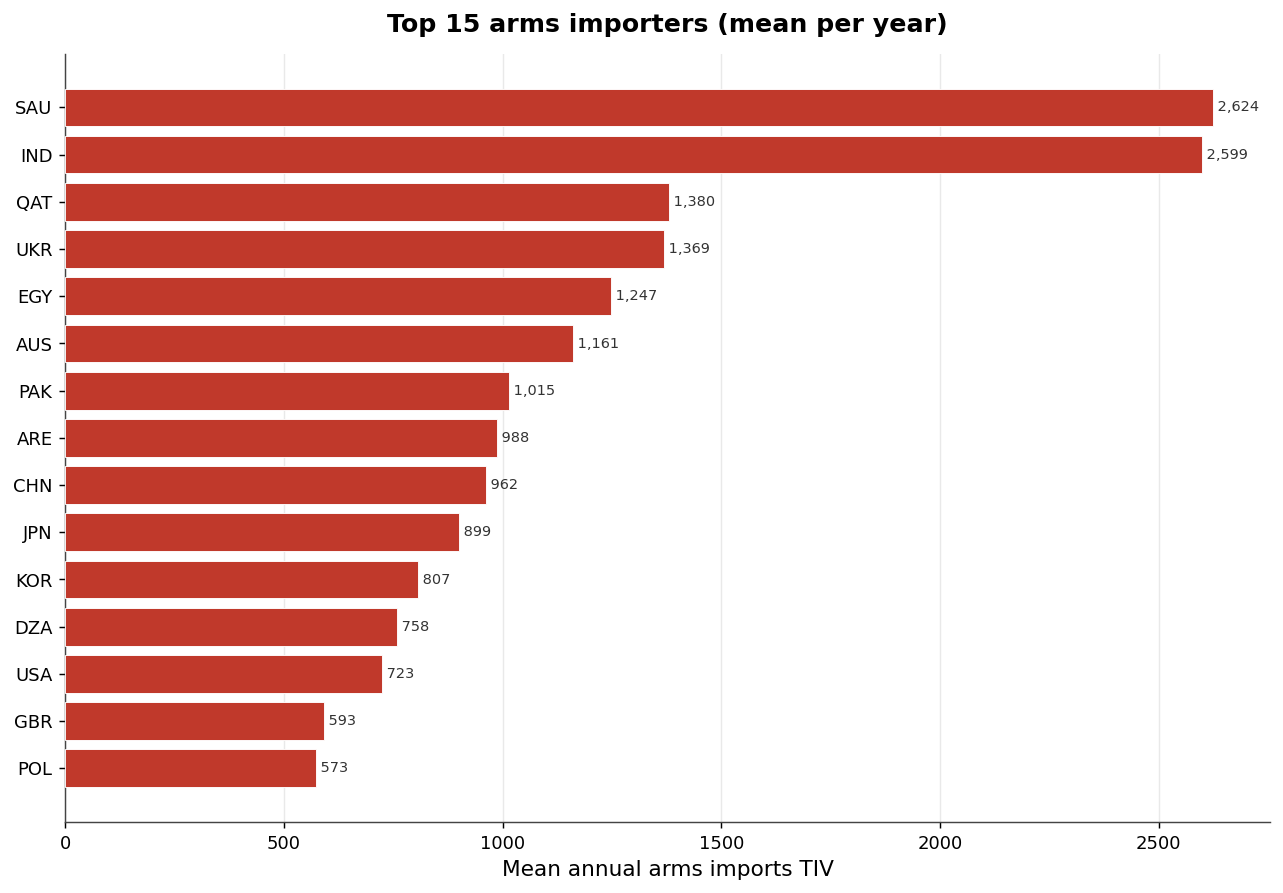

In [15]:
imp = sipri.groupby("iso3")["arms_imports_tiv"].mean().nlargest(15)[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp.index, imp.values, color=RED, edgecolor="white", linewidth=0.5, zorder=3)
for i, v in enumerate(imp.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8, color="#333333")
ax.set_xlabel("Mean annual arms imports TIV"); ax.set_title("Top 15 arms importers (mean per year)", pad=12)
ax.grid(axis="y", visible=False); fig.tight_layout(); plt.show()

The biggest importers are Saudi Arabia (around 2,600 TIV/yr) and India (a little under 2,600), then Qatar, Ukraine, Egypt, and Australia. These are the classic large arms purchasers.

Top 15 arms exporters by mean annual export TIV over the period.

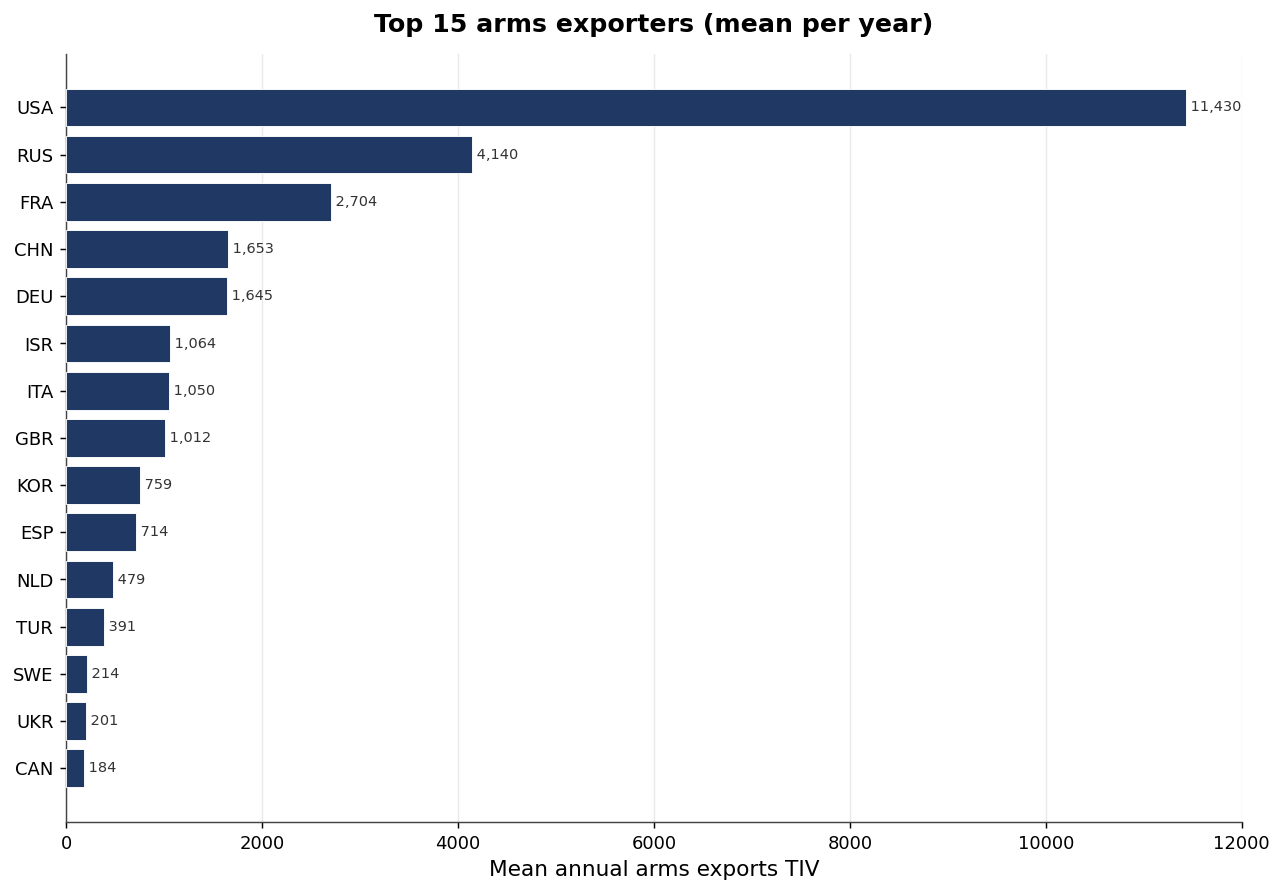

In [16]:
exp = sipri.groupby("iso3")["arms_exports_tiv"].mean().nlargest(15)[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(exp.index, exp.values, color=NAVY, edgecolor="white", linewidth=0.5, zorder=3)
for i, v in enumerate(exp.values):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8, color="#333333")
ax.set_xlabel("Mean annual arms exports TIV"); ax.set_title("Top 15 arms exporters (mean per year)", pad=12)
ax.grid(axis="y", visible=False); fig.tight_layout(); plt.show()

Exports are far more concentrated than imports: the US dominates (around 11,400 TIV/yr), then Russia (around 4,140), France, China, Germany, and Israel.

Arms imports over time for Ukraine and Russia.

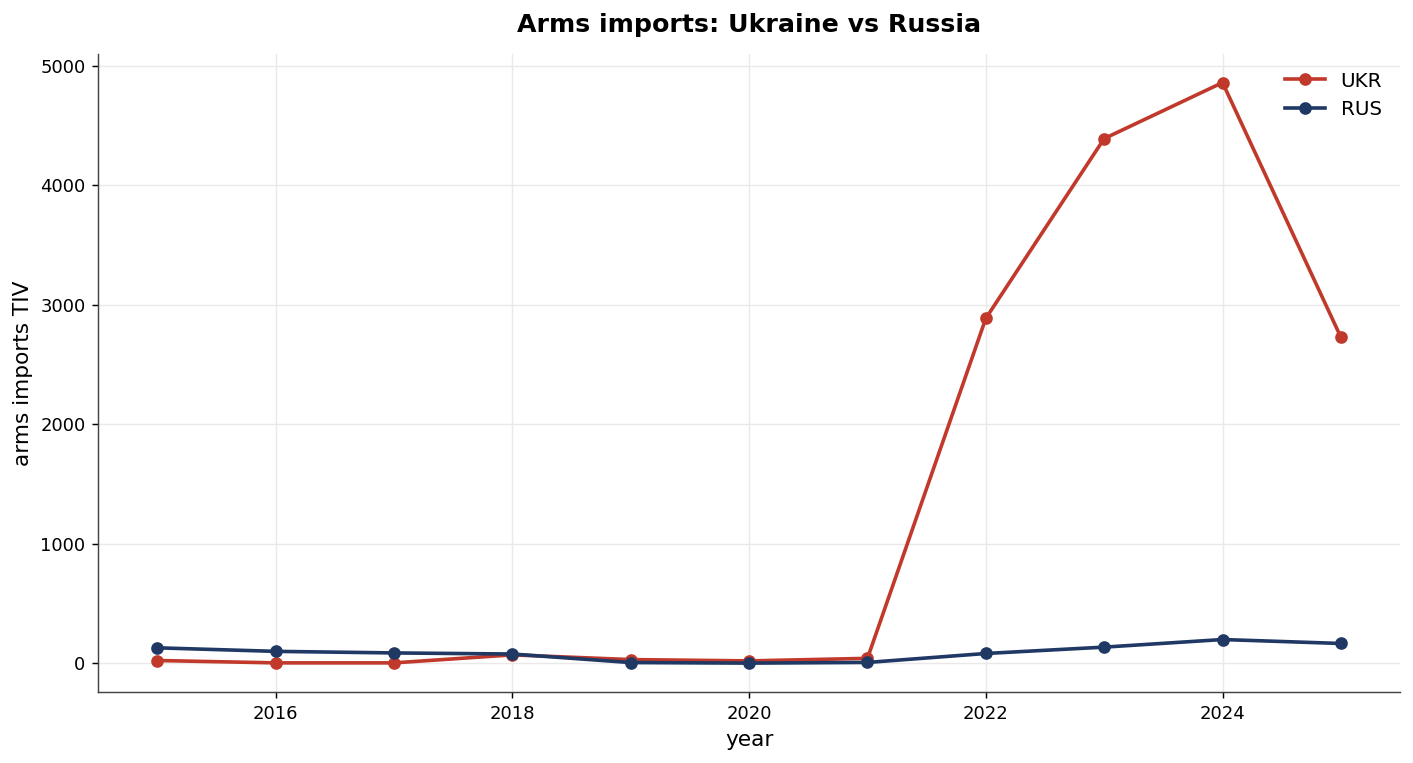

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
for c, col in [("UKR", RED), ("RUS", NAVY)]:
    s = sipri[sipri.iso3 == c].sort_values("year")
    ax.plot(s.year, s.arms_imports_tiv, marker="o", color=col, label=c, linewidth=2)
ax.set_xlabel("year"); ax.set_ylabel("arms imports TIV"); ax.set_title("Arms imports: Ukraine vs Russia", pad=12)
ax.legend(); fig.tight_layout(); plt.show()

The clearest story: Ukraine's imports were tiny before 2022, then exploded after the invasion. Russia stays low throughout (it is an exporter and already manifactures and exports arms).

Global total arms-transfer volume delivered per year (sum of import TIV across all countries).

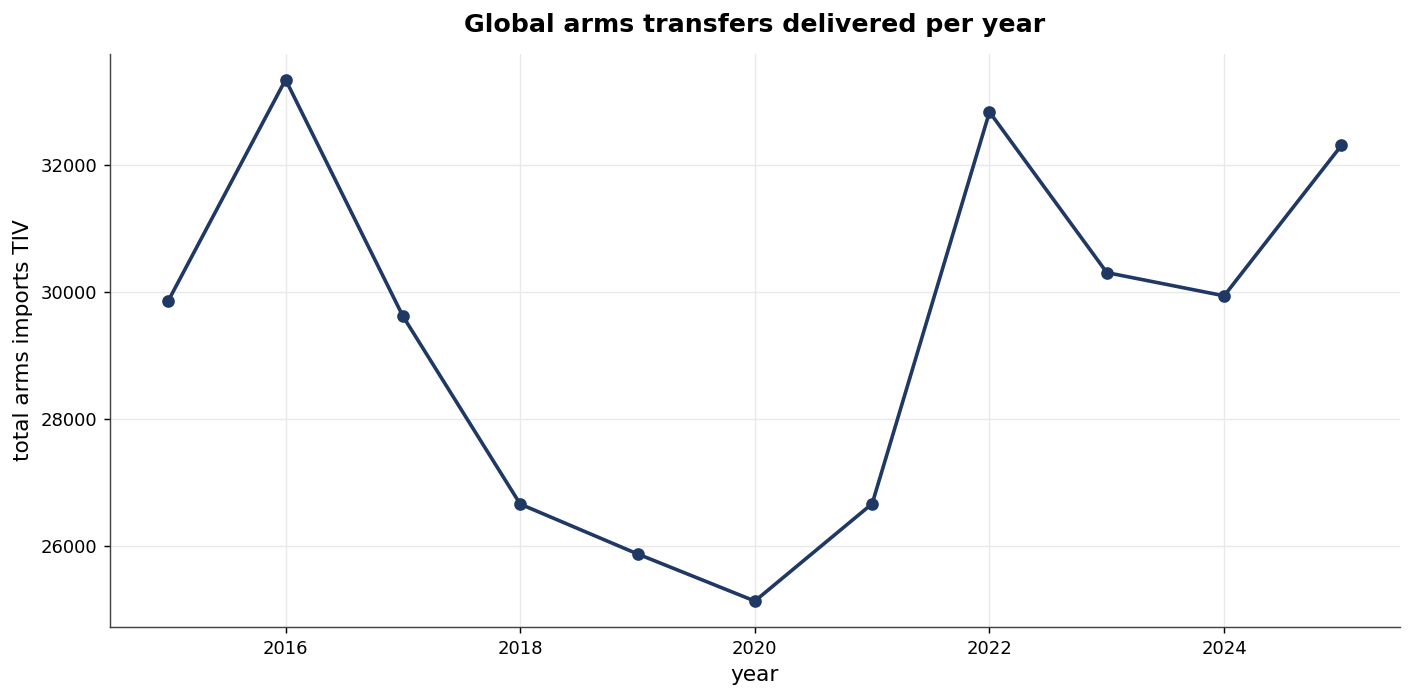

In [18]:
g = sipri.groupby("year")["arms_imports_tiv"].sum()
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(g.index, g.values, marker="o", color=NAVY, linewidth=2)
ax.set_xlabel("year"); ax.set_ylabel("total arms imports TIV"); ax.set_title("Global arms transfers delivered per year", pad=12)
fig.tight_layout(); plt.show()

Global delivered volume decreased from 2018 to 2020, then rose again from 2022 as the Russia-Ukraine war started.

I build a Sankey of the largest supplier-to-recipient arms flows for a chosen year, with a slider for how many flows to show. A Sankey shows who arms whom, which a table or bar chart cannot convey as clearly.

In [20]:
import plotly.graph_objects as go

_valid = d[d.recipient_iso.notna() & d.supplier_iso.notna()]
MAX_FLOWS = int(_valid.groupby("year").apply(lambda g: g.groupby(["supplier_iso", "recipient_iso"]).ngroups).max())

def flow_sankey(year=2023, top=15):
    f = (_valid[_valid.year == year].groupby(["supplier_iso", "recipient_iso"])["tiv_per_year"].sum()
         .reset_index().nlargest(top, "tiv_per_year"))
    srcs = sorted(f.supplier_iso.unique()); tgts = sorted(f.recipient_iso.unique())
    nodes = [s + " (from)" for s in srcs] + [t + " (to)" for t in tgts]
    si = {s: i for i, s in enumerate(srcs)}
    ti = {t: len(srcs) + i for i, t in enumerate(tgts)}
    fig = go.Figure(go.Sankey(
        node=dict(label=nodes, pad=14, thickness=14, color="#1F3864"),
        link=dict(source=f.supplier_iso.map(si), target=f.recipient_iso.map(ti),
                  value=f.tiv_per_year, color="rgba(192,57,43,0.4)")))
    fig.update_layout(title_text=f"Top {top} arms flows (supplier to recipient), {year}",
                      template="plotly_white", font=dict(family="DejaVu Sans", size=12),
                      height=600, margin=dict(l=10, r=10, t=55, b=10))
    fig.show()

interact(flow_sankey,
         year=IntSlider(min=2015, max=2025, value=2023, step=1, description="Year",
                        continuous_update=False, style=WSTYLE, layout=SLIDER),
         top=IntSlider(min=1, max=MAX_FLOWS, value=15, step=1, description="Top flows",
                       continuous_update=False, style=WSTYLE, layout=SLIDER))

interactive(children=(IntSlider(value=2023, continuous_update=False, description='Year', layout=Layout(width='…

<function __main__.flow_sankey(year=2023, top=15)>

Reading a recent year, the US is the dominant source feeding many recipients, with Russia, France, and Germany as secondary exporters, and flows into Ukraine swell after 2022.

## 5. Validate and Save

I check the final per-country-year table for duplicate iso3-year keys and any missing values before saving.

In [22]:
print("rows:", len(sipri), "| countries:", sipri.iso3.nunique(), "| years:", sipri.year.min(), "-", sipri.year.max())
print("duplicate iso3-year keys:", int(sipri.duplicated(["iso3", "year"]).sum()))
sipri.isna().sum().to_frame("n_missing")

rows: 1386 | countries: 174 | years: 2015 - 2025
duplicate iso3-year keys: 0


,n_missing
iso3,0
year,0
arms_imports_tiv,0
arms_exports_tiv,0
arms_n_suppliers,0


I order the columns, sort by country and year, confirm the keys are unique, and save the clean per-country-year table (all years 2015 to 2025; the master join applies its own window).

In [23]:
sip = (sipri[["iso3", "year", "arms_imports_tiv", "arms_exports_tiv", "arms_n_suppliers"]]
       .sort_values(["iso3", "year"]).reset_index(drop=True))
assert sip.duplicated(["iso3", "year"]).sum() == 0, "duplicate iso3-year keys!"
os.makedirs(OUT_DIR, exist_ok=True)
path = f"{OUT_DIR}/sipri_clean.csv"
sip.to_csv(path, index=False)
print("saved:", path, "|", sip.shape, "| countries:", sip.iso3.nunique())
sip.head()

saved: /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/data/interim/sipri/sipri_clean.csv | (1386, 5) | countries: 174


,iso3,year,arms_imports_tiv,arms_exports_tiv,arms_n_suppliers
0,AFG,2015,127.72,0.0,3
1,AFG,2016,223.74,0.0,4
2,AFG,2017,225.04,0.0,2
3,AFG,2018,274.84,0.0,3
4,AFG,2019,258.44,0.0,2


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.